<a href="https://colab.research.google.com/github/esprado1976/Trafico/blob/main/Proyecto_Tr%C3%A1fico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Este es un modelo de determinación de ruta para la ciudad de Buenos Aires, que toma el patron de calles, y le suma un análisis histórico de accidentes viales (basado en un dataset de accidentes viales 2016-2021)

Primero, preparamos el entorno. Estas librerías son el estándar de la industria para GIS en Python.

In [24]:
# Instalamos osmnx para manejo de redes viales y folium para mapas interactivos
!pip install osmnx folium geopandas requests

Cargamos las herramientas y configuramos osmnx para que use el caché (esto acelera todo).

In [25]:
import osmnx as ox
import folium
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# Configuración de visualización
%matplotlib inline

Consumimos los datos de accidentes desde el drive

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
import pandas as pd
import osmnx as ox
import folium
from geopy.geocoders import Nominatim

# 1. Ruta al archivo en la raíz de tu Drive
ruta_drive = '/content/drive/MyDrive/hechos.csv'

try:
    df_accidentes = pd.read_csv(ruta_drive)
    print(f"✅ Archivo leído correctamente desde Drive. Total filas: {len(df_accidentes)}")
except Exception as e:
    print(f"❌ Error al leer el archivo. Asegurate de que el nombre sea correcto. Error: {e}")

# 2. Limpieza de coordenadas (el dataset 'hechos' suele tener puntos '.' en vez de nulos)
df_accidentes['pos x'] = pd.to_numeric(df_accidentes['pos x'], errors='coerce')
df_accidentes['pos y'] = pd.to_numeric(df_accidentes['pos y'], errors='coerce')
df_accidentes = df_accidentes.dropna(subset=['pos x', 'pos y'])

# 3. Descarga del Mapa (Grafo vial)
# Ampliamos a 5km para tener buena cobertura de CABA
print("Descargando mapa vial de CABA...")
G = ox.graph_from_address("Obelisco, Buenos Aires, Argentina", dist=5000, network_type='drive')
G = ox.project_graph(G)

# 4. Asignación de Pesos de Riesgo Estadístico
for u, v, k, data in G.edges(data=True, keys=True):
    data['risk_weight'] = data['length'] # Peso base: distancia

print("Calculando penalizaciones por accidentes...")
# Encontramos los nodos más cercanos a cada siniestro del CSV
accident_nodes = ox.distance.nearest_nodes(G, df_accidentes['pos x'], df_accidentes['pos y'])

for i, node in enumerate(accident_nodes):
    if node in G:
        # Usamos N_VICTIMAS como multiplicador de riesgo
        victimas = df_accidentes.iloc[i]['N_VICTIMAS']
        for neighbor in G.neighbors(node):
            # Penalización fuerte: 1.5km "ficticios" por cada víctima en ese nodo
            G[node][neighbor][0]['risk_weight'] += (1500 * victimas)

print("✅ Análisis GIS completado. Grafo listo para ruteo.")

✅ Archivo leído correctamente desde Drive. Total filas: 696
Descargando mapa vial de CABA...
Calculando penalizaciones por accidentes...
✅ Análisis GIS completado. Grafo listo para ruteo.


Aquí es donde entra el GIS fuerte. Vamos a descargar la red de calles de un área específica (por ejemplo, el centro o un barrio) para calcular rutas.

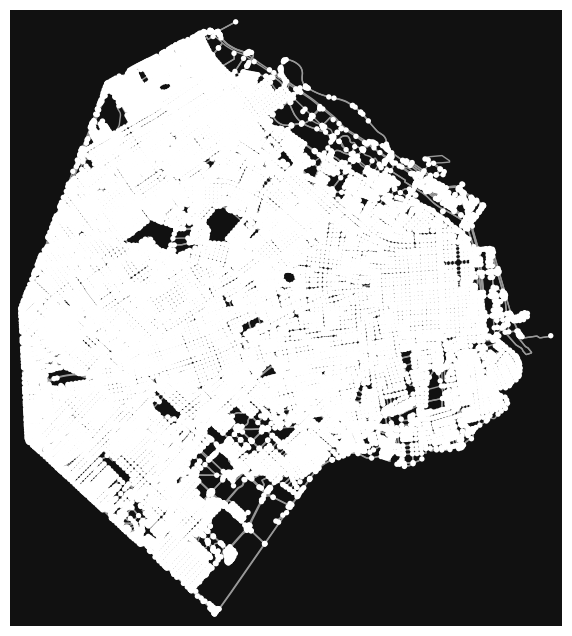

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [28]:
# Definimos el lugar
place_name = "Buenos Aires, Argentina"

# Descargamos el grafo de calles para conducir
G = ox.graph_from_place(place_name, network_type='drive')

# Proyectamos el grafo a coordenadas planas (importante para cálculos de distancia)
G_projected = ox.project_graph(G)

# Visualización rápida del grafo
ox.plot_graph(G)

¿Cómo afecta un accidente a una calle?
Vamos a asignar a cada accidente el "nodo" (intersección) más cercano del mapa.

In [29]:
# Convertimos los accidentes en un GeoDataFrame
geometry = [Point(xy) for xy in zip(df_accidentes['pos x'], df_accidentes['pos y'])]
gdf_accidentes = gpd.GeoDataFrame(df_accidentes, geometry=geometry, crs="EPSG:4326")

# Encontramos los nodos más cercanos en el grafo para cada accidente
# Nota: Esto puede tardar un poco dependiendo de la cantidad de puntos
nodes = ox.distance.nearest_nodes(G, df_accidentes['pos x'], df_accidentes['pos y'])

# Agregamos una métrica de "Peso de Accidente" al grafo
# Por defecto, todas las calles tienen peso = longitud.
# Nosotros le sumaremos una "penalización" si hay accidentes cerca.
for u, v, k, data in G.edges(data=True, keys=True):
    data['risk_weight'] = data['length'] # Empezamos con la longitud real

# Ejemplo: si un nodo tiene accidentes, penalizamos las calles que conectan a él
for node in nodes:
    if node in G:
        for neighbor in G.neighbors(node):
            # Penalizamos con 500 metros extra "ficticios" por cada accidente
            G[node][neighbor][0]['risk_weight'] += 500

Acá jugamos con las direcciones (latitud-longitud) de inicio y destino

In [30]:
def calcular_y_comparar_rutas(lat_origen, lon_origen, lat_destino, lon_destino, grafo, accidentes_df):
    # 1. Encontrar los nodos más cercanos
    orig_node = ox.distance.nearest_nodes(grafo, lon_origen, lat_origen)
    dest_node = ox.distance.nearest_nodes(grafo, lon_destino, lat_destino)

    # 2. Calcular las rutas (Corta vs Segura)
    ruta_corta = ox.shortest_path(grafo, orig_node, dest_node, weight='length')
    ruta_segura = ox.shortest_path(grafo, orig_node, dest_node, weight='risk_weight')

    # 3. Crear el mapa base
    m = folium.Map(location=[lat_origen, lon_origen], zoom_start=14, tiles="cartodbpositron")

    # Función auxiliar para convertir nodos en coordenadas de Folium
    def get_route_coords(ruta, g):
        coords = []
        for node in ruta:
            coords.append((g.nodes[node]['y'], g.nodes[node]['x']))
        return coords

    # 4. Dibujar Ruta Corta (ROJA)
    coords_corta = get_route_coords(ruta_corta, grafo)
    folium.PolyLine(coords_corta, color="red", weight=6, opacity=0.6, tooltip="Ruta más corta").add_to(m)

    # 5. Dibujar Ruta Segura (VERDE)
    coords_segura = get_route_coords(ruta_segura, grafo)
    folium.PolyLine(coords_segura, color="green", weight=4, opacity=0.8, tooltip="Ruta más segura").add_to(m)

    # 6. Marcadores e Incidentes
    folium.Marker([lat_origen, lon_origen], popup="Origen", icon=folium.Icon(color='blue')).add_to(m)
    folium.Marker([lat_destino, lon_destino], popup="Destino", icon=folium.Icon(color='black')).add_to(m)

    # Mostrar accidentes (limitamos a 200 para performance)
    for _, row in accidentes_df.head(200).iterrows():
        folium.CircleMarker(
            location=[row['pos y'], row['pos x']],
            radius=2, color='orange', fill=True, popup="Accidente"
        ).add_to(m)

    print("✅ Mapa generado: ROJO (Corta) vs VERDE (Segura)")
    return m

# Ejecución
mapa_final = calcular_y_comparar_rutas(lat_inicio, lon_inicio, lat_fin, lon_fin, G, df_accidentes)
mapa_final

✅ Mapa generado: ROJO (Corta) vs VERDE (Segura)


Ahora instalamos la librería de Geocoding

In [31]:
!pip install geopy

Esta función toma el texto, busca las coordenadas en Buenos Aires y lanza el cálculo de la ruta.

In [32]:
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut
import time

def obtener_coordenadas(direccion):
    """
    Convierte una dirección de texto en coordenadas Lat/Lon.
    Ejemplo: 'Av. Corrientes 1234, CABA, Argentina'
    """
    geolocator = Nominatim(user_agent="mi_analisis_vial_caba")

    # Le sumamos CABA y Argentina para que sea más preciso
    direccion_completa = f"{direccion}, Ciudad Autónoma de Buenos Aires, Argentina"

    try:
        location = geolocator.geocode(direccion_completa)
        if location:
            print(f"✅ Dirección encontrada: {location.address}")
            return location.latitude, location.longitude
        else:
            print(f"❌ No se encontró la dirección: {direccion}")
            return None, None
    except GeocoderTimedOut:
        return obtener_coordenadas(direccion)

# --- FLUJO PRINCIPAL ---

# 1. Pedir direcciones al usuario
direccion_a = "Av. San Juan 3967" # @param {type:"string"}
direccion_b = "Cerrito 740"    # @param {type:"string"}

print(f"Buscando coordenadas para: {direccion_a} y {direccion_b}...")

lat_a, lon_a = obtener_coordenadas(direccion_a)
lat_b, lon_b = obtener_coordenadas(direccion_b)

if lat_a and lat_b:
    # 2. Verificar que las coordenadas estén en el mapa G (opcional pero recomendado)
    # Si descargaste solo un barrio, esto podría fallar si la dirección está lejos.
    # Recomendación: Si cambias mucho de zona, vuelve a correr el Paso 4 con un área más grande.

    # 3. Llamar a nuestra función de mapa
    mapa_interactivo = calcular_y_comparar_rutas(lat_a, lon_a, lat_b, lon_b, G, df_accidentes)
    display(mapa_interactivo)
else:
    print("Hubo un error con las direcciones. Por favor, revisa que el número y calle sean correctos.")

Buscando coordenadas para: Av. San Juan 3967 y Cerrito 740...
✅ Dirección encontrada: 3967, Avenida San Juan, Boedo, Buenos Aires, Comuna 5, Ciudad Autónoma de Buenos Aires, C1236ABL, Argentina
✅ Dirección encontrada: Torre Mirafiori, 740, Cerrito, Microcentro, San Nicolás, Buenos Aires, Comuna 1, Ciudad Autónoma de Buenos Aires, C1055AAB, Argentina
✅ Mapa generado: ROJO (Corta) vs VERDE (Segura)
